In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_parquet(r'train.parquet' )
print(df)

              Date        X1        X2   X3        X4        X5 target
0       2020-12-16  1.518921  5.463154  1.0  2.718282  2.890372      0
1       2020-12-16  1.546509  5.458010  1.0  2.718282  2.833213      1
2       2020-12-16  1.645427  5.456560  1.0  7.389056  2.890372      1
3       2020-12-16  1.652022  5.458479  1.0  2.718282  2.890372      1
4       2020-12-16  1.695538  5.466709  1.0  2.718282  2.890372      0
...            ...       ...       ...  ...       ...       ...    ...
1639419 2024-11-26  1.000000  5.482346  1.0  1.000000  0.000000      0
1639420 2024-11-26  1.000000  5.486580  1.0  1.000000  0.000000      0
1639421 2024-11-26  1.000000  5.484797  1.0  1.000000  0.000000      0
1639422 2024-11-26  1.000000  5.483551  1.0  1.000000  0.000000      0
1639423 2024-11-26  1.000000  5.482928  1.0  1.000000  0.000000      0

[1639424 rows x 7 columns]


In [3]:
df.head()

,Date,X1,X2,X3,X4,X5,target
0,2020-12-16,1.518921,5.463154,1.0,2.718282,2.890372,0
1,2020-12-16,1.546509,5.458010,1.0,2.718282,2.833213,1
2,2020-12-16,1.645427,5.456560,1.0,7.389056,2.890372,1
3,2020-12-16,1.652022,5.458479,1.0,2.718282,2.890372,1
4,2020-12-16,1.695538,5.466709,1.0,2.718282,2.890372,0


In [4]:
df.tail()


,Date,X1,X2,X3,X4,X5,target
1639419,2024-11-26,1.0,5.482346,1.0,1.0,0.0,0
1639420,2024-11-26,1.0,5.486580,1.0,1.0,0.0,0
1639421,2024-11-26,1.0,5.484797,1.0,1.0,0.0,0
1639422,2024-11-26,1.0,5.483551,1.0,1.0,0.0,0
1639423,2024-11-26,1.0,5.482928,1.0,1.0,0.0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639424 entries, 0 to 1639423
Data columns (total 7 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   Date    1639424 non-null  datetime64[ns]
 1   X1      1639424 non-null  float64       
 2   X2      1639424 non-null  float64       
 3   X3      1639424 non-null  float64       
 4   X4      1639424 non-null  float64       
 5   X5      1639424 non-null  float64       
 6   target  1639424 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 87.6+ MB


In [6]:
df.columns

Index(['Date', 'X1', 'X2', 'X3', 'X4', 'X5', 'target'], dtype='object')

In [7]:
df.index

RangeIndex(start=0, stop=1639424, step=1)

In [8]:
df.isnull().sum()

Date      0
X1        0
X2        0
X3        0
X4        0
X5        0
target    0
dtype: int64

In [9]:
df.describe(include="all")

,Date,X1,X2,X3,X4,X5,target
count,1639424,1.639424e+06,1.639424e+06,1.639424e+06,1.639424e+06,1.639424e+06,1639424
unique,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,0
freq,NaN,NaN,NaN,NaN,NaN,NaN,1625386
mean,2022-12-03 07:23:43.817145600,1.139258e+00,5.488189e+00,4.110388e+32,2.706323e+29,1.187219e+00,NaN
min,2020-12-16 00:00:00,1.000000e+00,5.412539e+00,1.000000e+00,1.000000e+00,0.000000e+00,NaN
25%,2021-12-10 00:00:00,1.049171e+00,5.480597e+00,1.000000e+00,1.000000e+00,0.000000e+00,NaN
50%,2022-11-30 00:00:00,1.105171e+00,5.488979e+00,1.000000e+00,1.000000e+00,6.931472e-01,NaN
75%,2023-11-23 00:00:00,1.214096e+00,5.496717e+00,1.000000e+00,2.718282e+00,2.890372e+00,NaN
max,2024-12-11 00:00:00,4.014850e+00,5.541852e+00,1.651636e+38,5.540622e+34,3.465736e+00,NaN


In [10]:
df.corr(numeric_only=True)

,X1,X2,X3,X4,X5
X1,1.000000,-0.112976,-0.001039,0.001999,0.102220
X2,-0.112976,1.000000,-0.003727,0.000989,-0.264825
X3,-0.001039,-0.003727,1.000000,-0.000008,0.002301
X4,0.001999,0.000989,-0.000008,1.000000,0.000874
X5,0.102220,-0.264825,0.002301,0.000874,1.000000


<Axes: >

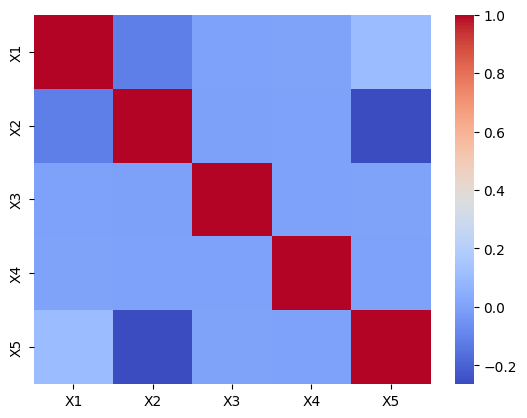

In [11]:
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm")

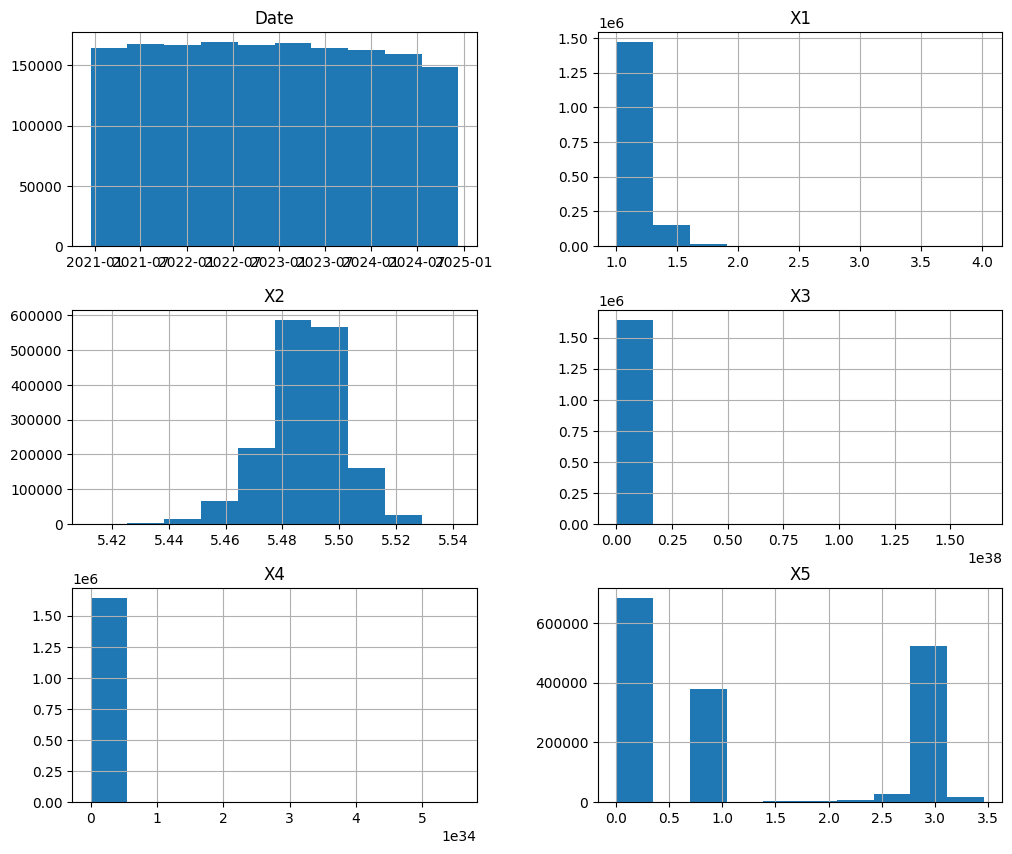

In [12]:
import matplotlib.pyplot as plt

df.hist(figsize=(12, 10))
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
from sklearn.linear_model import LogisticRegression

In [14]:
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df = df.drop('Date', axis=1)

In [15]:
X = df.drop('target', axis=1)
y = df['target'].astype(int)

In [16]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=1234
)

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [31]:
clf = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=6, 
    class_weight='balanced',
    random_state=1234
)
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1234
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [32]:
lr_model = LogisticRegression(
    class_weight='balanced', 
    solver='liblinear', 
    random_state=1234
)
lr_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1234
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [33]:
y_pred = clf.predict(X_val)
y_prob = clf.predict_proba(X_val)[:, 1]

In [34]:
print(classification_report(y_val, y_pred, target_names=['Normal', 'Anomaly']))

              precision    recall  f1-score   support

      Normal       1.00      0.94      0.97    325077
     Anomaly       0.12      0.93      0.22      2808

    accuracy                           0.94    327885
   macro avg       0.56      0.94      0.59    327885
weighted avg       0.99      0.94      0.96    327885



In [22]:
c_mat = confusion_matrix(y_val, y_pred)

In [23]:
group_counts = ["{0:0.0f}".format(value) for value in c_mat.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in c_mat.flatten() / np.sum(c_mat)]
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2, 2)

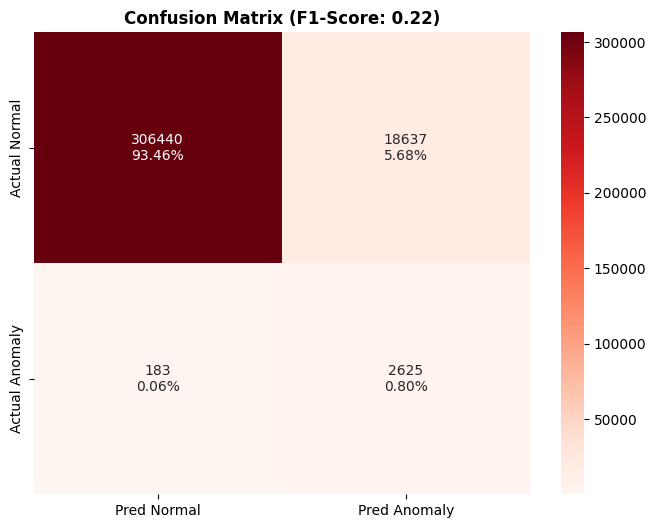

In [24]:
plt.figure(figsize=(8, 6))
sns.heatmap(c_mat, annot=labels, fmt='', cmap='Reds', 
            xticklabels=['Pred Normal', 'Pred Anomaly'], 
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title(f'Confusion Matrix (F1-Score: {f1_score(y_val, y_pred):.2f})', fontweight='bold')
plt.show()

In [25]:
fpr, tpr, _ = roc_curve(y_val.astype(int), y_prob)
roc_auc = auc(fpr, tpr)

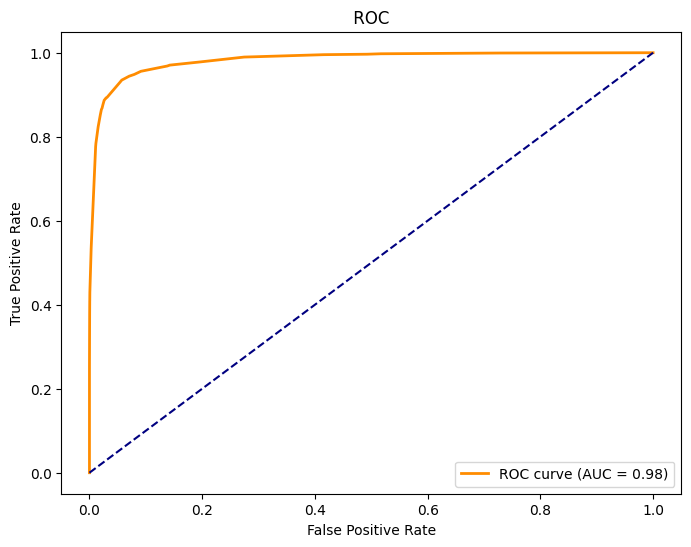

In [26]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' ROC ')
plt.legend(loc="lower right")
plt.show()

In [27]:
cm_percent = c_mat.astype('float') / c_mat.sum(axis=1)[:, np.newaxis]
print(f"Normal Accuracy: {cm_percent[0,0]:.2%}")
print(f"Anomaly  Accuracy: {cm_percent[1,1]:.2%}")

Normal Accuracy: 94.27%
Anomaly  Accuracy: 93.48%


In [28]:
models = {'Decision Tree':clf, 'Logistic Regression': lr_model}
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [29]:
for name, model in models.items():
    # Use scaled data for LR
    X_v = X_val_scaled if name == 'Logistic Regression' else X_val
    
    y_pred = model.predict(X_v)
    y_prob = model.predict_proba(X_v)[:, 1]
    
    # Metrics
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    roc_auc = auc(fpr, tpr)
    f1 = f1_score(y_val, y_pred)

C:\Users\charc\AppData\Local\Temp\ipykernel_30648\3076407988.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


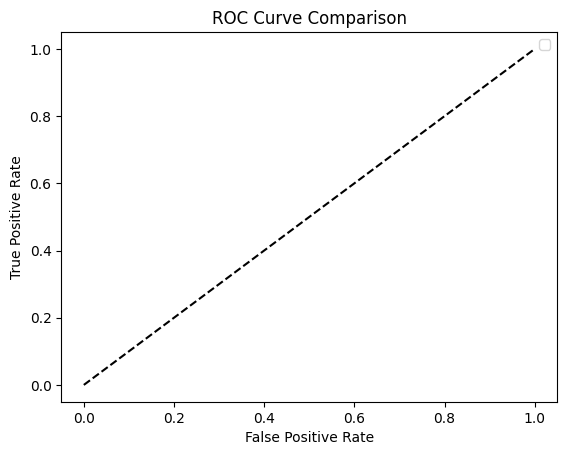

In [30]:
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()